In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.1.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,total_positive_emissions,total_negative_emissions,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,180.946992,-65.431373,-0.397260
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,130.106944,-46.488820,-0.511648
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,81.331598,-66.341535,-0.508951
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,152.754671,-62.483625,-0.414841
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,125.921317,-71.490619,-0.630830


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if "emissions" in col] + ["technical_cost"]
target_cols

['total_positive_emissions', 'total_negative_emissions', 'technical_cost']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [8]:
training_df[target_cols].describe()

,total_positive_emissions,total_negative_emissions,technical_cost
count,9.840000e+02,984.000000,9.840000e+02
mean,2.305855e+05,-64.998926,4.608358e+03
std,3.211814e+06,9.441110,6.423630e+04
min,8.133160e+01,-88.015709,-8.778638e-01
25%,1.256212e+02,-71.897965,-5.467405e-01
50%,1.423788e+02,-64.839876,-4.432861e-01
75%,1.642911e+02,-58.131104,-3.399439e-01
max,6.097508e+07,-42.853784,1.219499e+06


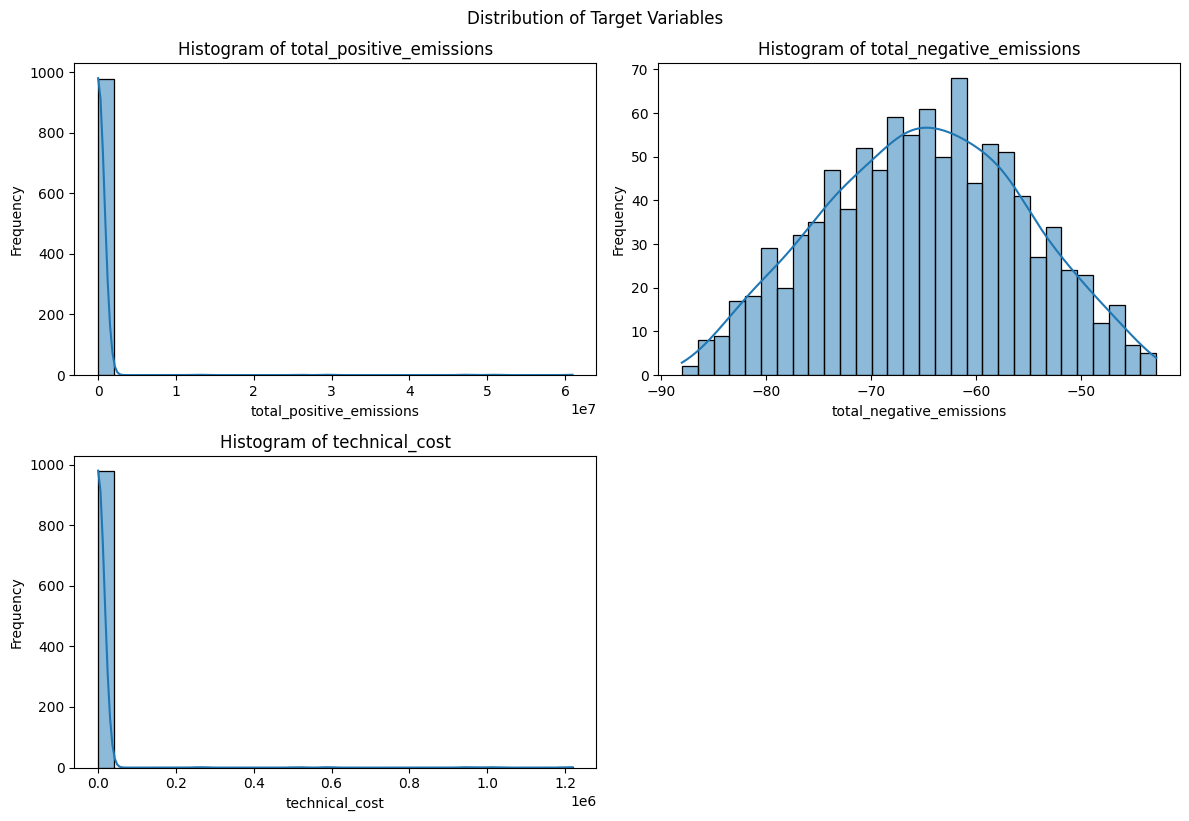

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")


In [10]:
edau.get_target_var_corr(training_df, "total_positive_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000
technical_cost                 : 1.0000



In [11]:
edau.get_target_var_corr(training_df, "total_negative_emissions")


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6409



In [12]:
edau.get_target_var_corr(training_df, "technical_cost")


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
total_positive_emissions       : 1.0000



In [13]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [14]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.6097560975609756, 'technical_cost': 0.6097560975609756}


## Data Cleaning

In [15]:
dcu = DataCleaningUtils()

In [16]:
training_df.shape

(984, 49)

In [17]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (978, 49)


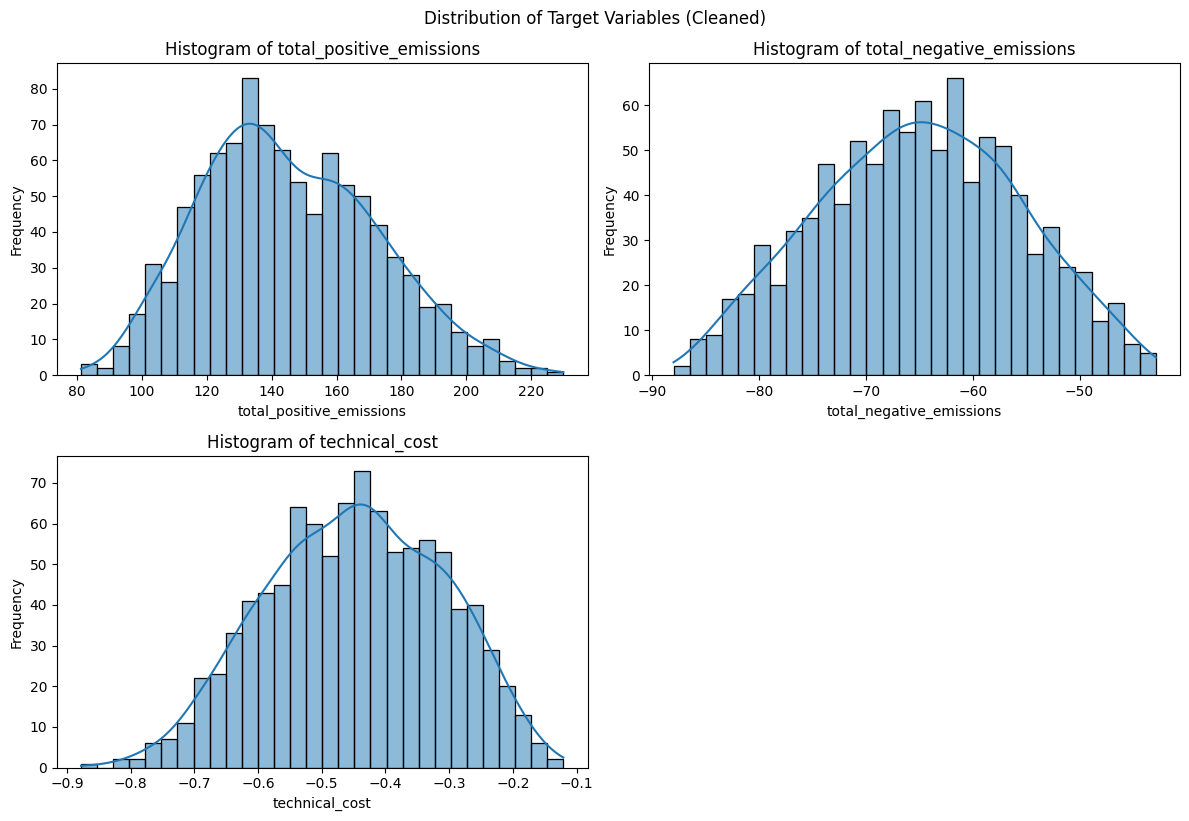

In [18]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [19]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.10224948875255625, 'technical_cost': 0.10224948875255625}


In [20]:
edau.get_target_var_corr(training_df_cleaned, "total_positive_emissions")
edau.get_target_var_corr(training_df_cleaned, "total_negative_emissions")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000
group_34_nemomod_en            : 0.8048
group_26_frac_inen_energy      : 0.3218
group_17_frac_trns_fuelmix     : 0.2394
group_8_frac_fgtv              : 0.1731
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1420
total_negative_emissions       : 0.1265
group_47_scalar_scoe_heat_energy_demand : 0.1110
group_46_scalar_scoe_appliance_energy_demand : 0.1050


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.6427
total_positive_emissions       : 0.1265


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
group_15_frac_ippu_production_with_co2_capture : 0.7829
gr

In [21]:
training_df_cleaned[target_cols].describe()

,total_positive_emissions,total_negative_emissions,technical_cost
count,978.000000,978.000000,978.000000
mean,145.330282,-65.032435,-0.448263
std,26.739150,9.454020,0.137661
min,81.331598,-88.015709,-0.877864
25%,125.574830,-71.909259,-0.547248
50%,142.158298,-64.942610,-0.443723
75%,163.761190,-58.176236,-0.341836
max,229.854443,-42.853784,-0.120613


In [22]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [23]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [24]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [25]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [26]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB ===
total_positive_emissions      
  Train → MAE: 0.0065, RMSE: 0.0091, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 7.1270, RMSE: 9.2188, R²: 0.8831, SMAPE: 4.9%
total_negative_emissions      
  Train → MAE: 0.0135, RMSE: 0.0192, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 7.2110, RMSE: 8.3330, R²: 0.2390, SMAPE: 11.3%
technical_cost                
  Train → MAE: 0.0004, RMSE: 0.0006, R²: 1.0000, SMAPE: 0.1%
   Test → MAE: 0.0292, RMSE: 0.0368, R²: 0.9360, SMAPE: 6.9%

=== MeanBaseline ===
total_positive_emissions      
  Train → MAE: 21.8238, RMSE: 26.6508, R²: 0.0000, SMAPE: 15.1%
   Test → MAE: 22.7864, RMSE: 27.0365, R²: -0.0056, SMAPE: 15.8%
total_negative_emissions      
  Train → MAE: 7.7495, RMSE: 9.4231, R²: 0.0000, SMAPE: 12.0%
   Test → MAE: 7.7838, RMSE: 9.5528, R²: -0.0001, SMAPE: 12.1%
technical_cost                
  Train → MAE: 0.1115, RMSE: 0.1355, R²: 0.0000, SMAPE: 25.8%
   Test → MAE: 0.1203, RMSE: 0.1455, R²: -0.0009, SMAPE: 27.9%

=== MedianBaseline ===
total_pos

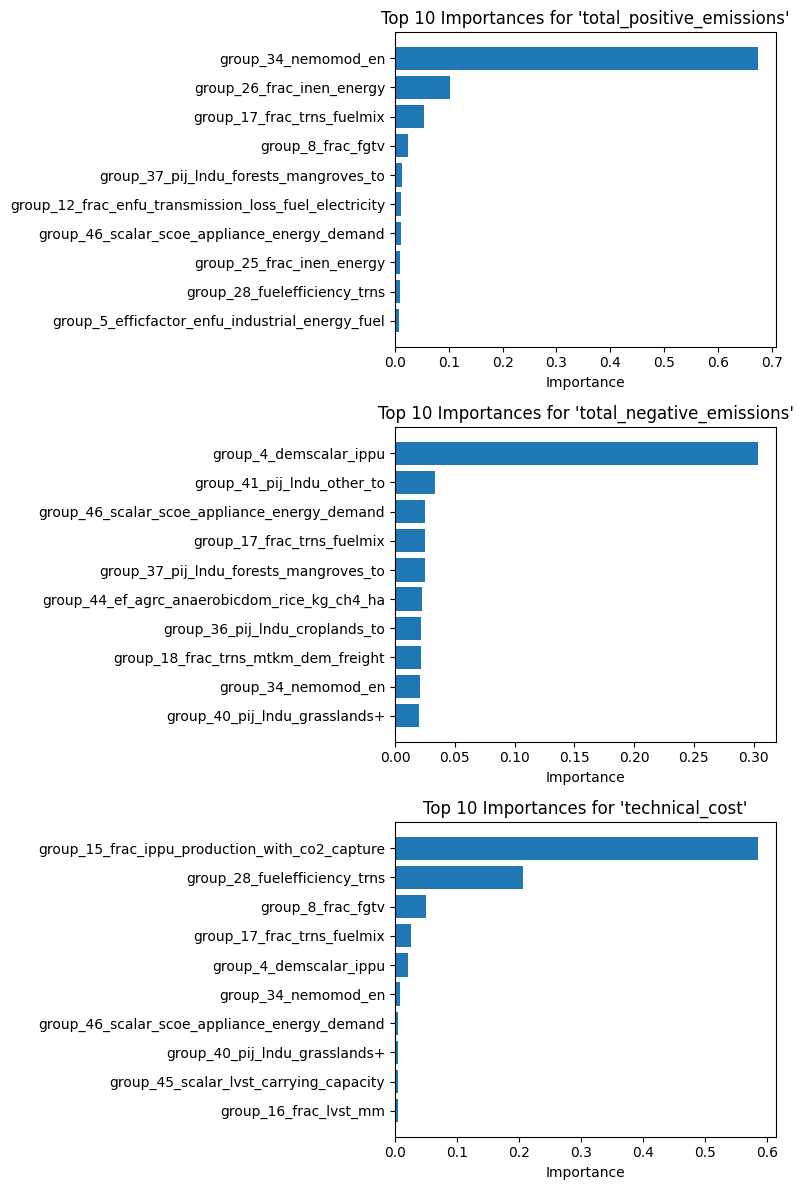

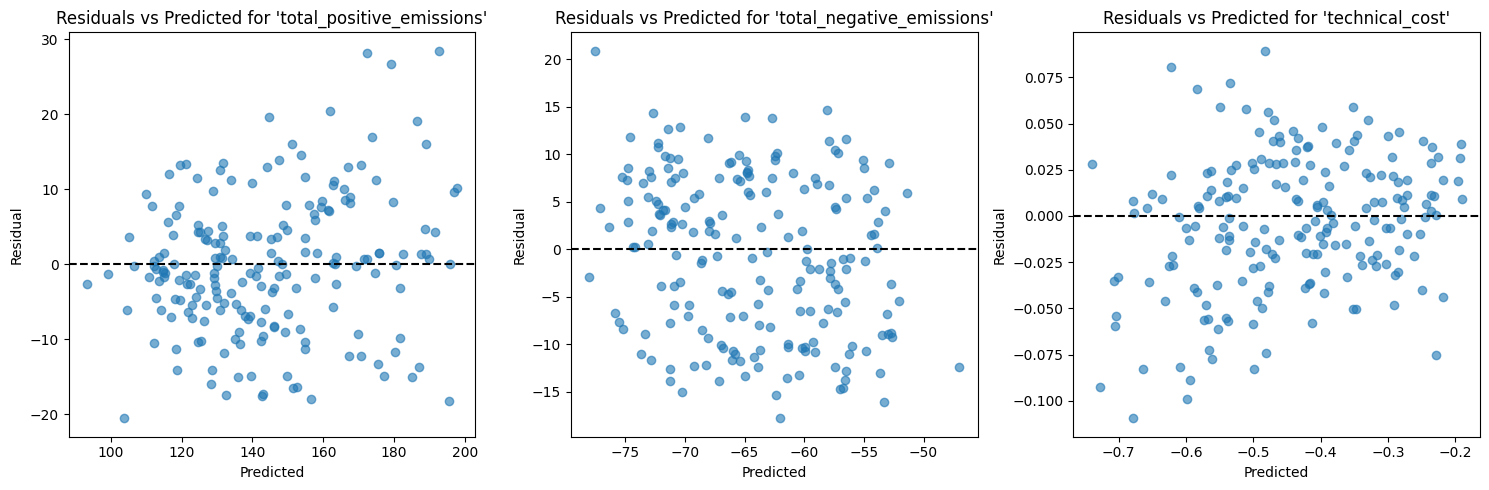

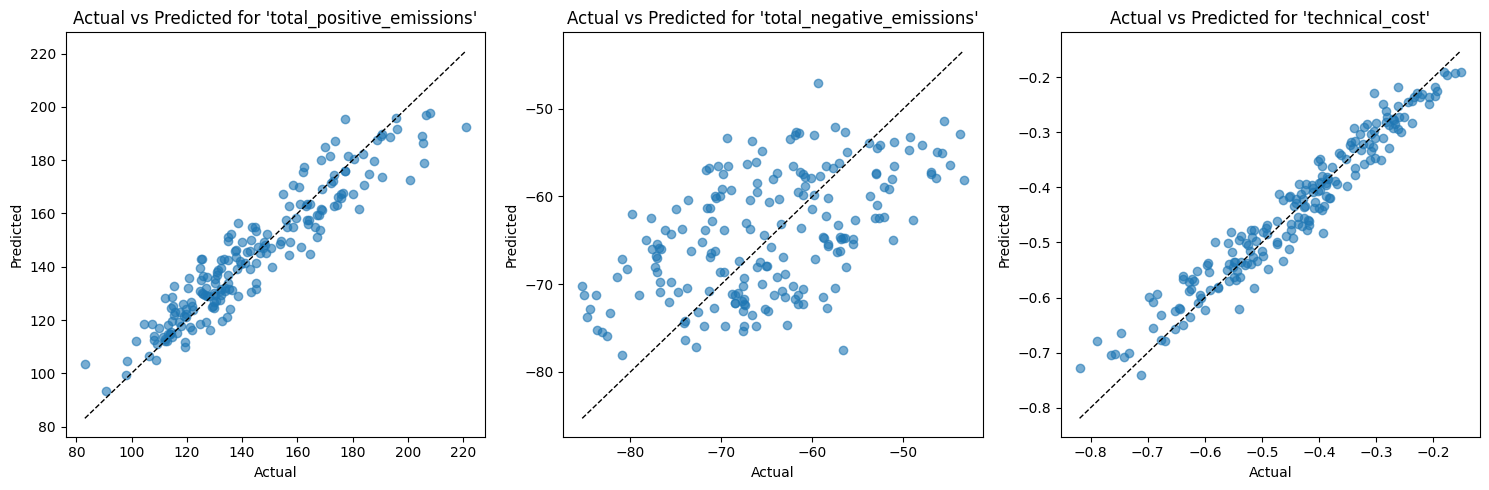

In [27]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["total_positive_emissions","total_negative_emissions", "technical_cost"])
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [28]:
training_df_cleaned.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,total_positive_emissions,total_negative_emissions,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,180.946992,-65.431373,-0.397260
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,130.106944,-46.488820,-0.511648
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,81.331598,-66.341535,-0.508951
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,152.754671,-62.483625,-0.414841
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,125.921317,-71.490619,-0.630830


In [29]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["total_positive_emissions", "total_negative_emissions", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_38_pij_lndu_forests_primary_to,group_39_pij_lndu_forests_secondary_to,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand
0,0.952436,0.360397,0.20299,0.995748,0.369859,0.91992,0.47845,0.445798,0.490988,0.51028,...,0.941385,0.873715,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757


In [30]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   total_positive_emissions  total_negative_emissions  technical_cost
0                180.954987                -65.421967       -0.396895


In [31]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Model xgb_pipeline.pkl already exists at /home/tony-ubuntu/decision_sciences/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline.pkl. Make sure you don't overwrite an existing model.


In [32]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [33]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   total_positive_emissions  total_negative_emissions  technical_cost
0                1085.73584                -392.57486       -2.382501
